# 04 – Simulated Annealing for Playlist Optimization
**Project**: Playlist Optimizer  
**Author**: S33mi  

Optimize an ordered playlist with Simulated Annealing (SA).

- State = ordered list of unique track indices (fixed length)
- Energy = negative of `total_playlist_score` (we minimize energy ≡ maximize score)
- Neighborhood moves: swap, insertion, reverse segment, replace one track
- Cooling: geometric schedule

Data is loaded via **URL method** (Colab-friendly).  
Final section compares SA vs Genetic Algorithm vs baselines.

## 1. Setup & Imports

In [115]:
import os
from io import BytesIO
import random
from copy import deepcopy
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import joblib
from sklearn.metrics.pairwise import cosine_similarity
from tqdm.auto import tqdm
import warnings

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
pd.set_option("display.max_colwidth", 90)

print("Libraries loaded.")

Libraries loaded.


## 2. Load Artifacts via URL

In [116]:
BASE = "https://raw.githubusercontent.com/S33mi/spotify-music-recommender/main"

URL_PART1 = f"{BASE}/data/processed/spotify_with_clusters_part1.csv"
URL_PART2 = f"{BASE}/data/processed/spotify_with_clusters_part2.csv"
URL_X     = f"{BASE}/data/processed/X_scaled.npy"
URL_MOOD  = f"{BASE}/data/models/mood_labels.pkl"

def download(url: str) -> bytes:
    print(f"Downloading {url} ...")
    r = requests.get(url, timeout=120)
    r.raise_for_status()
    return r.content

print("Loading track metadata ...")
p1 = download(URL_PART1)
p2 = download(URL_PART2)
with open("_part1.tmp", "wb") as f: f.write(p1)
with open("_part2.tmp", "wb") as f: f.write(p2)
df = pd.concat([pd.read_csv("_part1.tmp"), pd.read_csv("_part2.tmp")], ignore_index=True)
os.remove("_part1.tmp"); os.remove("_part2.tmp")

X = np.load(BytesIO(download(URL_X)))
mood_labels = joblib.load(BytesIO(download(URL_MOOD)))
if "mood" not in df.columns and "cluster" in df.columns:
    df["mood"] = df["cluster"].map(mood_labels)

assert len(df) == len(X)
print(f"Loaded {len(df)} tracks | X shape = {X.shape}")

Loading track metadata ...
Loaded 89741 tracks | X shape = (89741, 10)


### Pre Processing

In order to avoid `NaN` value data in selected playlist do the same for GA (if required)

In [117]:
# -------------------------------------------------
# Clean the dataset
# -------------------------------------------------
print("Original shape:", df.shape)

# 1. Remove rows with missing critical information
critical_cols = ["track_name", "artists", "track_genre"]
df = df.dropna(subset=critical_cols)

# 2. Fill missing numerical values
for col in ["energy", "tempo", "popularity"]:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

# 3. Reset index so iloc works perfectly (very important!)
df = df.reset_index(drop=True)

# 4. Keep X aligned with the cleaned df
# (Assuming X was loaded in the same order as original df)
X = X[df.index] if len(X) != len(df) else X   # safe alignment

print("Cleaned shape:", df.shape)
print("Remaining NaNs in critical columns:")
print(df[critical_cols].isna().sum())

Original shape: (89741, 23)
Cleaned shape: (45081, 23)
Remaining NaNs in critical columns:
track_name     0
artists        0
track_genre    0
dtype: int64


## 3. Scoring Functions

In [118]:
#Updated
def playlist_energy_tempo(df, indices):
    """Safely extract energy and tempo, filling missing values."""
    energy = df.iloc[indices]["energy"].values if "energy" in df.columns else np.zeros(len(indices))
    tempo  = df.iloc[indices]["tempo"].values  if "tempo"  in df.columns else np.zeros(len(indices))

    # Fill NaNs with column median (or 0.5 / 120 as reasonable defaults)
    energy = np.nan_to_num(energy, nan=np.nanmedian(energy) if not np.all(np.isnan(energy)) else 0.5)
    tempo  = np.nan_to_num(tempo,  nan=np.nanmedian(tempo)  if not np.all(np.isnan(tempo))  else 120.0)

    return energy.astype(float), tempo.astype(float)

def smoothness_score(energy, tempo, w_energy=0.6, w_tempo=0.4):
    if len(energy) < 2:
        return 1.0
    e_jump = np.abs(np.diff(energy)).mean()
    t_jump = (np.abs(np.diff(tempo)) / 50.0).mean()
    return 1.0 / (1.0 + w_energy * e_jump + w_tempo * t_jump)

#updated
def smoothness_score(energy, tempo, w_energy=0.6, w_tempo=0.4):
    """Robust smoothness score that never returns NaN."""
    if len(energy) < 2:
        return 1.0

    # Extra safety
    energy = np.nan_to_num(energy, nan=0.5)
    tempo  = np.nan_to_num(tempo,  nan=120.0)

    e_jump = np.abs(np.diff(energy)).mean()
    t_jump = (np.abs(np.diff(tempo)) / 50.0).mean()

    score = 1.0 / (1.0 + w_energy * e_jump + w_tempo * t_jump)

    # Final protection
    if np.isnan(score) or np.isinf(score):
        return 0.5
    return float(score)

def seed_similarity_score(X, seed_idx, playlist_indices):
    sims = cosine_similarity(X[seed_idx].reshape(1, -1), X[playlist_indices])[0]
    return float(sims.mean())

def diversity_score(X, playlist_indices):
    if len(playlist_indices) < 2:
        return 1.0
    sim = cosine_similarity(X[playlist_indices])
    triu = sim[np.triu_indices(len(playlist_indices), k=1)]
    return float(1.0 - triu.mean())

def mood_consistency_score(df, playlist_indices, seed_idx):
    if "mood" not in df.columns:
        return 0.5
    seed_mood = df.iloc[seed_idx]["mood"]
    return float((df.iloc[playlist_indices]["mood"] == seed_mood).mean())

# def total_playlist_score(
#     df, X, seed_idx, playlist_indices,
#     w_smooth=0.30, w_sim=0.30, w_div=0.25, w_mood=0.15
# ):
#     energy, tempo = playlist_energy_tempo(df, playlist_indices)
#     comps = {
#         "smoothness":       smoothness_score(energy, tempo),
#         "seed_similarity":  seed_similarity_score(X, seed_idx, playlist_indices),
#         "diversity":        diversity_score(X, playlist_indices),
#         "mood_consistency": mood_consistency_score(df, playlist_indices, seed_idx),
#     }
#     comps["total"] = (
#         w_smooth * comps["smoothness"]
#         + w_sim   * comps["seed_similarity"]
#         + w_div   * comps["diversity"]
#         + w_mood  * comps["mood_consistency"]
#     )
#     return comps["total"], comps

#updated
def total_playlist_score(
    df, X, seed_idx, playlist_indices,
    w_smooth=0.30, w_sim=0.30, w_div=0.25, w_mood=0.15
):
    try:
        playlist_indices = [int(i) for i in playlist_indices]  # force integers

        energy, tempo = playlist_energy_tempo(df, playlist_indices)

        comps = {
            "smoothness":       smoothness_score(energy, tempo),
            "seed_similarity":  seed_similarity_score(X, seed_idx, playlist_indices),
            "diversity":        diversity_score(X, playlist_indices),
            "mood_consistency": mood_consistency_score(df, playlist_indices, seed_idx),
        }

        total = (
            w_smooth * comps["smoothness"]
            + w_sim   * comps["seed_similarity"]
            + w_div   * comps["diversity"]
            + w_mood  * comps["mood_consistency"]
        )

        # Final safety
        if np.isnan(total) or np.isinf(total):
            total = 0.0

        comps["total"] = float(total)
        return comps["total"], comps

    except Exception as e:
        print(f"Scoring error: {e}")
        return 0.0, {
            "smoothness": 0.0,
            "seed_similarity": 0.0,
            "diversity": 0.0,
            "mood_consistency": 0.0,
            "total": 0.0
        }

## 4. Display Helpers

In [119]:
def show_playlist(df, indices, title="Playlist"):
    cols = ["track_name", "artists", "track_genre", "popularity"]
    for c in ["mood", "energy", "tempo"]:
        if c in df.columns:
            cols.append(c)
    out = df.iloc[indices][cols].copy()
    out.index = range(1, len(out) + 1)
    print(title)
    display(out)
    return out

def plot_energy_tempo(df, indices, title="Energy & Tempo"):
    energy, tempo = playlist_energy_tempo(df, indices)
    x = np.arange(1, len(indices) + 1)
    fig, ax1 = plt.subplots(figsize=(11, 4))
    ax1.plot(x, energy, "o-", color="steelblue")
    ax1.set_ylabel("Energy", color="steelblue")
    ax1.set_xlabel("Position")
    ax2 = ax1.twinx()
    ax2.plot(x, tempo, "s--", color="darkorange")
    ax2.set_ylabel("Tempo (BPM)", color="darkorange")
    plt.title(title)
    fig.tight_layout()
    plt.show()

## 5. Seed Track & SA Parameters

### Important Parameters

- `T0 = 0.15` → Starting temperature  
- `ALPHA = 0.995` → Cooling rate (closer to 1 = slower cooling)  
- `T_MIN` → Stopping temperature  
- `ITERS_PER_TEMP` → Number of attempts at each temperature  

**Tip**: Slower cooling (higher `ALPHA`) usually gives better results but takes more time.

In [120]:
SEED_QUERY = "blinding lights"
PLAYLIST_LENGTH = 12

mask = df["track_name"].str.lower().str.contains(SEED_QUERY.lower(), na=False)
if mask.sum() == 0:
    seed_pos = 0
    print("Query not found – using first track.")
else:
    seed_pos = df.index.get_loc(mask.idxmax())

seed = df.iloc[seed_pos]
print("Seed track:")
print(f"  {seed['track_name']} — {seed['artists']}")
print(f"  Genre: {seed.get('track_genre')} | Mood: {seed.get('mood')} | Pop: {seed['popularity']}")

# Simulated Annealing parameters
T0 = 0.15                 # initial temperature
T_MIN = 1e-4              # stopping temperature
ALPHA = 0.995             # cooling rate (geometric)
ITERS_PER_TEMP = 40       # trials at each temperature
MAX_STEPS = 12000         # hard safety limit
RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

Seed track:
  Blinding Lights — Kidz Bop Kids
  Genre: children | Mood: Acoustic / Chill | Pop: 0.0


## 6. Neighborhood Moves

In [121]:
def random_playlist(n_tracks, length, seed_idx):
    candidates = list(range(n_tracks))
    candidates.remove(seed_idx)
    return random.sample(candidates, length)

def neighbor(state, n_tracks, seed_idx):
    """
    Generate a neighbor by one of:
    1. Swap two positions
    2. Move one track to a new position (insertion)
    3. Reverse a small segment
    4. Replace one track with a new unused track
    """
    s = state[:]
    length = len(s)
    move = random.random()

    if move < 0.30:
        # swap
        i, j = random.sample(range(length), 2)
        s[i], s[j] = s[j], s[i]

    elif move < 0.55:
        # insertion
        i, j = random.sample(range(length), 2)
        track = s.pop(i)
        s.insert(j, track)

    elif move < 0.75:
        # reverse segment
        i, j = sorted(random.sample(range(length), 2))
        s[i:j+1] = reversed(s[i:j+1])

    else:
        # replace one track
        pos = random.randrange(length)
        used = set(s)
        candidates = [t for t in range(n_tracks) if t != seed_idx and t not in used]
        if candidates:
            s[pos] = random.choice(candidates)

    return s

def energy(state, df, X, seed_idx):
    """Energy to minimize = negative of total score."""
    score, _ = total_playlist_score(df, X, seed_idx, state)
    return -score


## 7. Run Simulated Annealing

### What is Simulated Annealing (SA)?
Simulated Annealing is a probabilistic optimization algorithm inspired by the annealing process in metallurgy.  
It is particularly good at escaping local optima.

- We try to **minimize energy** (in our case, energy = –playlist score).
- At high temperature → SA accepts worse solutions easily (exploration).
- As temperature decreases → SA becomes more greedy (exploitation).

### Key Components Used in this Notebook

| Component              | Implementation                          | Purpose |
|------------------------|-----------------------------------------|--------|
| State                  | Ordered list of track indices           | A complete playlist |
| Energy                 | Negative of total playlist score        | We minimize energy |
| Neighborhood Moves     | Swap, Insertion, Reverse, Replace       | Generate nearby solutions |
| Cooling Schedule       | Geometric (`T = T * α`)                 | Gradually reduce temperature |
| Acceptance Criterion   | Metropolis rule                         | Accept worse solutions with probability `exp(-ΔE / T)` |

In [122]:
n_tracks = len(df)

# Start from a reasonably good solution (nearest-neighbor) for faster convergence
def nn_playlist(X, seed_idx, length):
    sims = cosine_similarity(X[seed_idx].reshape(1, -1), X)[0]
    sims[seed_idx] = -np.inf
    return np.argsort(sims)[-length:][::-1].tolist()

current = nn_playlist(X, seed_pos, PLAYLIST_LENGTH)
current_energy = energy(current, df, X, seed_pos)

best = current[:]
best_energy = current_energy

T = T0
history_energy = [current_energy]
history_best = [best_energy]
history_T = [T]
step = 0

print("Running Simulated Annealing ...")
pbar = tqdm(total=MAX_STEPS, desc="SA steps")

while T > T_MIN and step < MAX_STEPS:
    for _ in range(ITERS_PER_TEMP):
        cand = neighbor(current, n_tracks, seed_pos)
        cand_energy = energy(cand, df, X, seed_pos)
        delta = cand_energy - current_energy

        # Accept better solutions always; accept worse with probability exp(-delta / T)
        if delta < 0 or random.random() < math.exp(-delta / T):
            current = cand
            current_energy = cand_energy
            if current_energy < best_energy:
                best = current[:]
                best_energy = current_energy

        history_energy.append(current_energy)
        history_best.append(best_energy)
        history_T.append(T)
        step += 1
        pbar.update(1)

        if step >= MAX_STEPS:
            break

    T *= ALPHA

pbar.close()
print(f"\nFinished after {step} steps")
print(f"Best energy: {best_energy:.4f}  →  best score = {-best_energy:.4f}")

Running Simulated Annealing ...


SA steps:   0%|          | 0/12000 [00:00<?, ?it/s]


Finished after 12000 steps
Best energy: -0.7311  →  best score = 0.7311


## 8. Convergence Plots

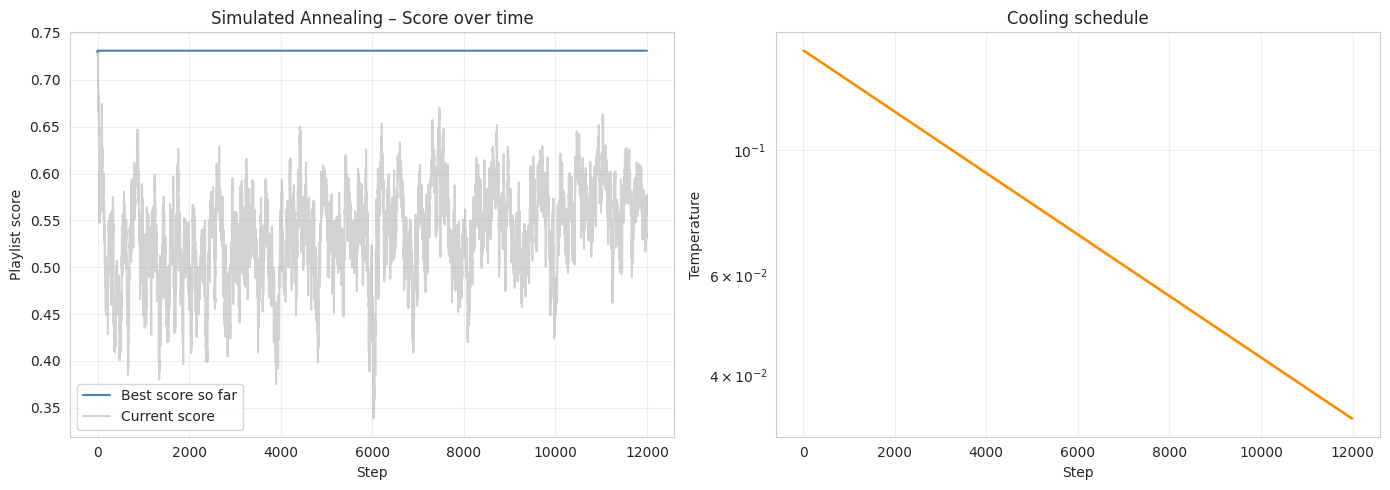

In [123]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot([-e for e in history_best], color="steelblue", label="Best score so far")
axes[0].plot([-e for e in history_energy], color="gray", alpha=0.35, label="Current score")
axes[0].set_xlabel("Step")
axes[0].set_ylabel("Playlist score")
axes[0].set_title("Simulated Annealing – Score over time")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_T, color="darkorange")
axes[1].set_xlabel("Step")
axes[1].set_ylabel("Temperature")
axes[1].set_title("Cooling schedule")
axes[1].set_yscale("log")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Best Playlist Found by SA

### Why use SA for Playlist Optimization?
- Playlist optimization is a **combinatorial** problem (huge search space).
- The landscape has many local optima.
- SA is strong at **local refinement** and can improve solutions found by other methods (e.g. Genetic Algorithm).

=== Simulated Annealing – Best Playlist ===
Component scores: {'smoothness': 0.925, 'seed_similarity': 0.98, 'diversity': 0.039, 'mood_consistency': 1.0, 'total': 0.731}
SA Optimized Playlist


,track_name,artists,track_genre,popularity,mood,energy,tempo
1,1+1,Ready Kirken,folk,46.0,Acoustic / Chill,0.306083,1.757979
2,Mob Rule,Bad//Dreems,garage,29.0,Acoustic / Chill,0.621745,1.490093
3,My Person,Spencer Crandall,country,55.0,Acoustic / Chill,0.477554,1.459347
4,My Person,Spencer Crandall,country,61.0,Acoustic / Chill,0.461966,1.457886
5,Atrakce,PAWLIE POIZN;Medooza,emo,36.0,Acoustic / Chill,0.391819,1.588907
6,Manohari,Divya Kumar;Neeti Mohan,folk,55.0,Acoustic / Chill,0.645128,1.259728
7,The Middle,Jimmy Eat World,alt-rock,0.0,Acoustic / Chill,0.832187,1.331215
8,The Middle,Jimmy Eat World,alt-rock,0.0,Acoustic / Chill,0.832187,1.331215
9,The Middle,Jimmy Eat World,alt-rock,81.0,Acoustic / Chill,0.836084,1.331248
10,Kahani Baaki Hai,Divya Kumar,folk,34.0,Acoustic / Chill,0.723069,1.593489


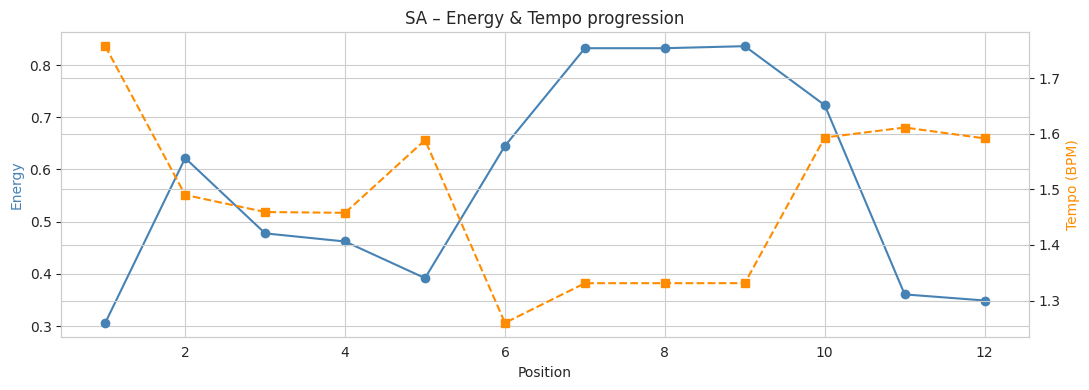

In [124]:
sa_score, sa_comps = total_playlist_score(df, X, seed_pos, best)

print("=== Simulated Annealing – Best Playlist ===")
print("Component scores:", {k: round(v, 3) for k, v in sa_comps.items()})
show_playlist(df, best, title="SA Optimized Playlist")
plot_energy_tempo(df, best, title="SA – Energy & Tempo progression")

## 10. Final Comparison: Random / NN / GA (if available) / SA

In [125]:
def random_pl(n_tracks, length, seed_idx, random_state=42):
    rng = np.random.default_rng(random_state)
    candidates = np.delete(np.arange(n_tracks), seed_idx)
    return rng.choice(candidates, size=length, replace=False).tolist()

rand_idx = random_pl(n_tracks, PLAYLIST_LENGTH, seed_pos)
nn_idx   = nn_playlist(X, seed_pos, PLAYLIST_LENGTH)

rand_score, rand_comps = total_playlist_score(df, X, seed_pos, rand_idx)
nn_score, nn_comps     = total_playlist_score(df, X, seed_pos, nn_idx)

rows = [
    {"method": "Random",            **{k: round(v, 3) for k, v in rand_comps.items()}},
    {"method": "Nearest-Neighbor",  **{k: round(v, 3) for k, v in nn_comps.items()}},
    {"method": "Simulated Annealing", **{k: round(v, 3) for k, v in sa_comps.items()}},
]

# -------------------------------------------------
# Load Genetic Algorithm result (local or via URL)
# -------------------------------------------------
ga_path = "data/ga_result.pkl"
ga_url  = "https://raw.githubusercontent.com/S33mi/playlist-optimizer/main/models/ga_pre_processed_result.pkl"

ga_ind = None
ga_comps = None

if os.path.exists(ga_path):
    # 1. Try loading from local file
    try:
        ga_data = joblib.load(ga_path)
        ga_ind = ga_data["best_individual"]
        _, ga_comps = total_playlist_score(df, X, seed_pos, ga_ind)
        print("Loaded GA result from local file: data/ga_result.pkl")
    except Exception as e:
        print(f"Failed to load local GA result: {e}")

elif True:  # try downloading from GitHub
    try:
        print(f"Local GA result not found. Trying to download from:\n{ga_url}")
        response = requests.get(ga_url, timeout=60)
        response.raise_for_status()

        ga_data = joblib.load(BytesIO(response.content))
        ga_ind = ga_data["best_individual"]
        _, ga_comps = total_playlist_score(df, X, seed_pos, ga_ind)
        print("Successfully downloaded and loaded GA result from GitHub.")
    except Exception as e:
        print(f"Could not download GA result: {e}")
        print("Comparison will show Random / NN / SA only.")

if ga_comps is not None:
    rows.insert(2, {"method": "Genetic Algorithm", **{k: round(v, 3) for k, v in ga_comps.items()}})
comparison = pd.DataFrame(rows).set_index("method")
display(comparison)

Local GA result not found. Trying to download from:
https://raw.githubusercontent.com/S33mi/playlist-optimizer/main/models/ga_pre_processed_result.pkl
Successfully downloaded and loaded GA result from GitHub.


,smoothness,seed_similarity,diversity,mood_consistency,total
method,,,,,
Random,0.485,0.014,1.065,0.5,0.491
Nearest-Neighbor,0.921,0.980,0.039,1.0,0.730
Genetic Algorithm,0.937,0.173,0.658,1.0,0.647
Simulated Annealing,0.925,0.980,0.039,1.0,0.731


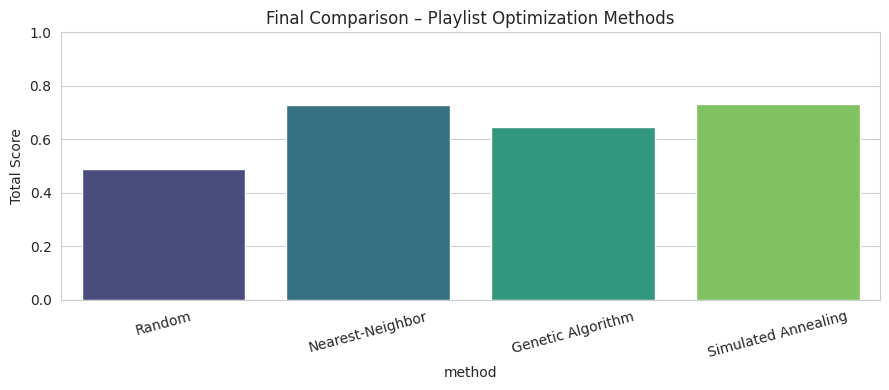

In [126]:
plt.figure(figsize=(9, 4))
sns.barplot(x=comparison.index, y=comparison["total"], palette="viridis")
plt.ylabel("Total Score")
plt.title("Final Comparison – Playlist Optimization Methods")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### Strengths of Simulated Annealing
- Very good at escaping local minima (especially early in the search).
- Simple to implement.
- Works well as a **local improver** after a global method (like GA).

### Limitations
- Can still get stuck if cooling is too fast.
- Performance depends heavily on the neighborhood design and cooling schedule.
- Does not keep a population (only one current solution).

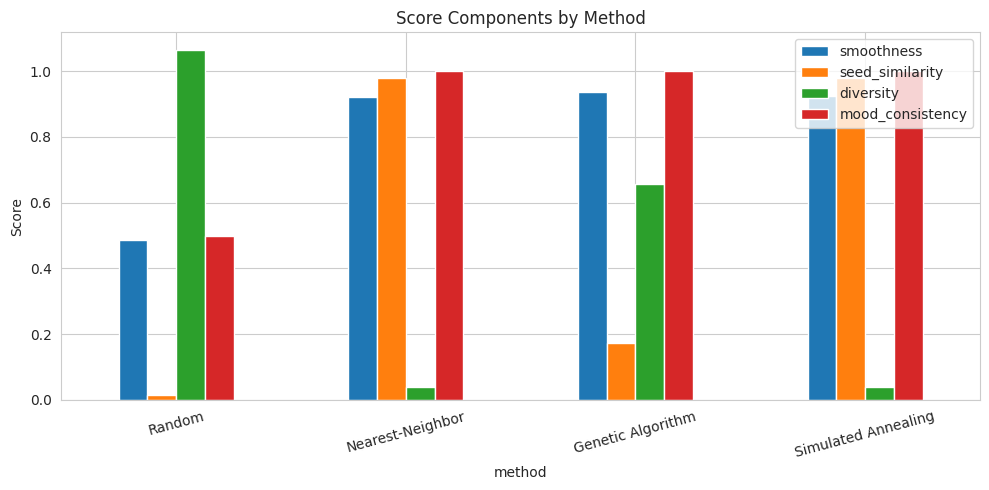

In [127]:
# Component breakdown
comp_cols = ["smoothness", "seed_similarity", "diversity", "mood_consistency"]
comparison[comp_cols].plot(kind="bar", figsize=(10, 5))
plt.title("Score Components by Method")
plt.ylabel("Score")
plt.xticks(rotation=15)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

## 11. Summary

| Method | Style | Notes |
|--------|-------|-------|
| Random | Baseline | Lower bound |
| Nearest-Neighbor | Greedy | Strong on seed similarity, weaker on flow/diversity |
| Genetic Algorithm | Population-based | Good global exploration |
| Simulated Annealing | Local search + temperature | Strong refinement, often best or near-best score |

SA typically improves flow (smoothness) while keeping competitive similarity and diversity.

Possible next steps:
- Combine GA (exploration) + SA (local refinement)
- Multi-objective / Pareto optimization
- Gradio demo that optimizes a playlist from a seed track
- Export optimized playlist to Spotify

## 12. (Optional) Save SA result

In [128]:
os.makedirs("data", exist_ok=True)
joblib.dump(
    {
        "best_individual": best,
        "best_score": -best_energy,
        "history_energy": history_energy,
        "history_best": history_best,
        "history_T": history_T,
        "seed_pos": seed_pos,
        "playlist_length": PLAYLIST_LENGTH,
    },
    "data/sa_result.pkl"
)
print("Saved data/sa_result.pkl")

Saved data/sa_result.pkl


# Learning Notes – Simulated Annealing for Playlist Optimization

### What is Simulated Annealing?
A probabilistic optimization method inspired by annealing in metallurgy.  
It explores widely at high temperature and becomes more greedy as temperature cools.

### Why SA?
- Good at escaping local optima
- Strong at refining solutions
- Works well on combinatorial problems like playlist ordering

### Key Design Choices
- **State**: Ordered list of track indices
- **Energy**: Negative of playlist score (we minimize it)
- **Moves**: Swap, Insertion, Reverse segment, Replace track
- **Cooling**: Geometric schedule (`T = T × α`)

### Important Lessons

1. **Neighborhood design matters a lot** — using multiple move types (swap + insert + reverse + replace) improves performance.
2. Starting from a good initial solution (Nearest Neighbor) helps SA converge faster.
3. Cooling rate is critical — too fast = gets stuck, too slow = wastes time.
4. Always clean the dataset first to avoid NaN issues.
5. SA is excellent for **refinement**, while Genetic Algorithm is better for **global exploration**.
6. Hybrid idea: Run GA first → take best solution → improve it further with SA.

### Best Practice
For playlist optimization:
- Use **Genetic Algorithm** for broad exploration.
- Then apply **Simulated Annealing** on the best GA solution for fine-tuning.

### Summary
Simulated Annealing is simple, effective, and particularly strong when used to improve solutions found by global methods like Genetic Algorithms.
